# Statistical Baseline

In this notebook we take the tools that we built till now and put them to work on a real ECG record. 

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from m1_defect_anomaly_2026.preprocessing import preprocess, bandpass, FS
from m1_defect_anomaly_2026.beats import load_record_data, aggregate_to_beats
from m1_defect_anomaly_2026.detectors import zscore_detector


from pathlib import Path

REPO_ROOT=Path.cwd()
if REPO_ROOT.name=="notebooks":
    REPO_ROOT=REPO_ROOT.parent

DATA =str(REPO_ROOT/"data"/"raw")


## 1 - Compare raw and filtered signal

Our signal doesn't only have a heartbeat but also a slow drift of the whole trace caused by the patient breathing and moving. That is why our bandpass filter keeps only 0.5 to 40 Hz so we can remove the drifts and the high frequency noise and keep only the heartbeat.

Text(0.5, 0, 'time in seconds')

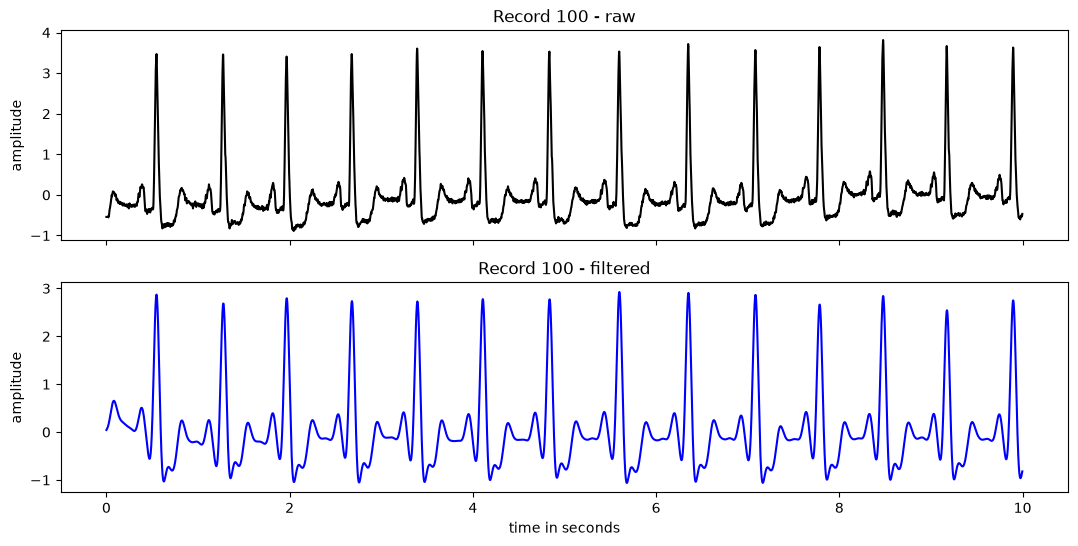

In [8]:
raw =load_record_data("105",data_dir=DATA,preprocess_method="none").signal
filtered=load_record_data("105",data_dir=DATA,preprocess_method="bandpass").signal

seconds = 10
n=seconds*FS
t=np.arange(n)/FS 

fig, axes = plt.subplots(2,1,figsize=(13,6), sharex=True)
axes[0].plot(t,raw[:n],"k")
axes[0].set_title("Record 100 - raw")
axes[0].set_ylabel("amplitude")
axes[1].plot(t,filtered[:n],"b")
axes[1].set_title("Record 100 - filtered")
axes[1].set_ylabel("amplitude")
axes[1].set_xlabel("time in seconds")


Both panels show the same ten seconds of record 100. The raw signal has a noisy, slightly drifting baseline between beats but the filtered signal sits flat and clean. Every heartbeat stays in the same place and the filter only removed the noise and drift, it didn't touch the beats.

## 2 - Run the Z-score detector

We use the Z-score detector to check the data point by point and gives each one a score. If we have a high score that means that the point is far from its normal range, and if we have a low score that means that the point is close to normal. Here we aren't deciding what is normal and what isn't, we are just calculating the scores.

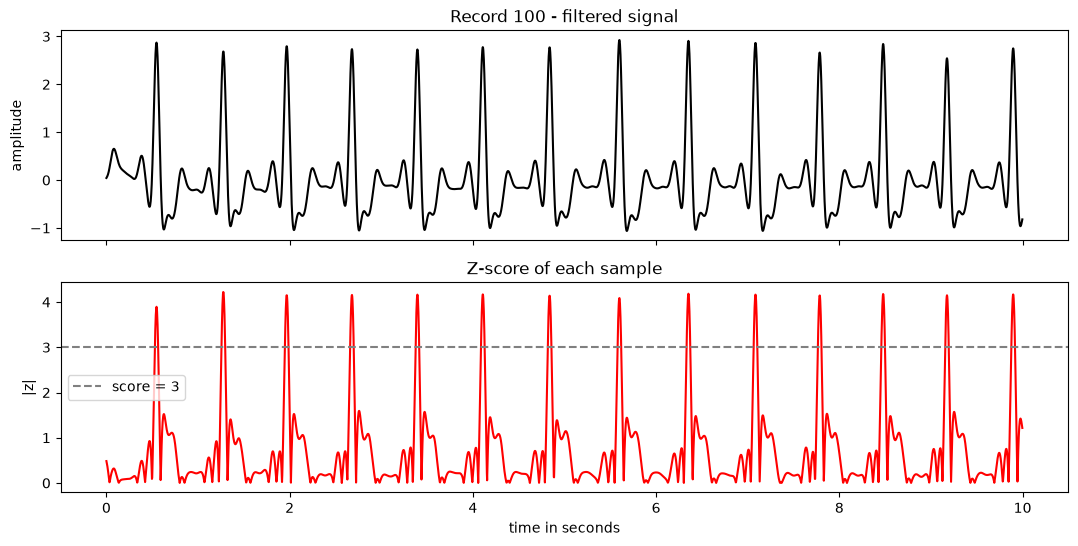

In [9]:
scores =zscore_detector(filtered,window=FS)

fig, axes=plt.subplots(2,1,figsize=(13,6),sharex=True)
axes[0].plot(t,filtered[:n],"k")
axes[0].set_title("Record 100 - filtered signal")
axes[0].set_ylabel("amplitude")
axes[1].plot(t,scores[:n],"r")
axes[1].axhline(3,linestyle="--",color="gray",label="score = 3")
axes[1].set_title("Z-score of each sample")
axes[1].set_ylabel("|z|")
axes[1].set_xlabel("time in seconds")
axes[1].legend()

The red score spikes on every heartbeat and crosses the threshold. With a one-second window, the detector reacts to how sharp each beat is rather than whether it's abnormal and a normal R-peak is the sharpest feature in an ECG. So the plain Z-score at this window size behaves more like a heartbeat detector than an anomaly detector. This is a key finding and it motivates the stronger methods we build next (wider windows, beat-template comparison, and frequency features).

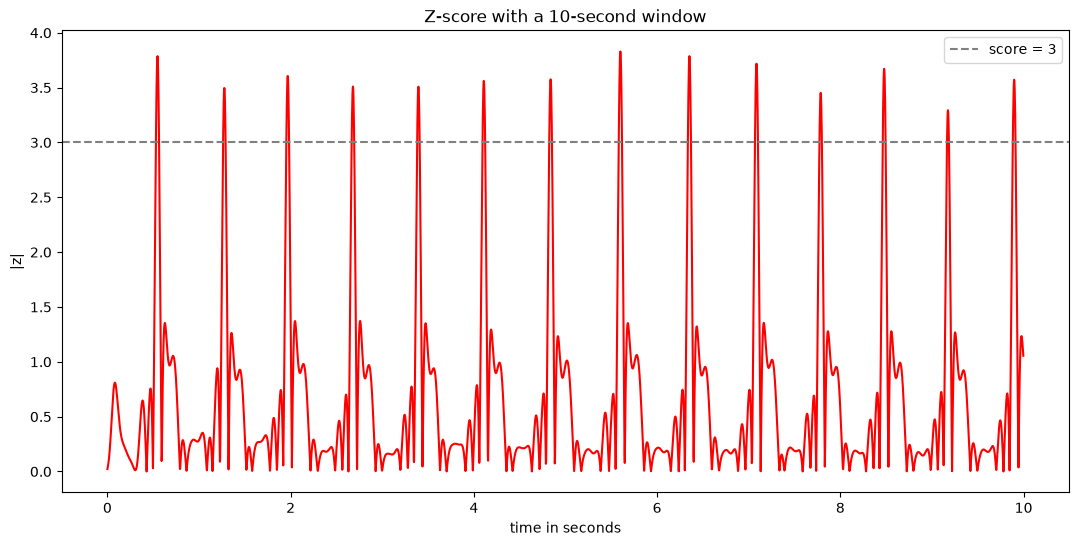

In [10]:
scores_wide =zscore_detector(filtered,window=10*FS) # 10 sec window

fig, axes=plt.subplots(1,1,figsize=(13,6),sharex=True)

axes.plot(t,scores_wide[:n],"r")
axes.axhline(3,linestyle="--",color="gray",label="score = 3")
axes.set_title("Z-score with a 10-second window")
axes.set_ylabel("|z|")
axes.set_xlabel("time in seconds")
axes.legend()

Making the window wider (10 seconds instead of 1) helped a little. But the detector still flags most normal heartbeats. This tells me the problem isn't the window size but the Z-score reacts to how sharp a beat is and normal heartbeats are sharp. So a wider window softens the issue but doesn't solve it. To really separate abnormal beats from normal ones, we need methods that compare each beat to a typical beat, or look at the frequency content.

## 3 - Filter reduces false positive?

We need to take a look at the false positive. In our case we use a dectector that could flag the sample that is anomalous when it is just part of a normal heartbeat.

In [11]:
scores_raw=zscore_detector(raw,window=FS)
scores_filtered=zscore_detector(filtered, window=FS)

threshold=3.0
flags_raw=(scores_raw >=threshold).sum()
flags_filtered=(scores_filtered>=threshold).sum()
total =len(raw)
print(f"raw signal:{flags_raw:6d} samples flagged ({100*flags_raw/total:.2f}%)")
print(f"filtered signal:{flags_filtered:6d} samples flagged ({100*flags_filtered/total:.2f}%)")
print(f"filtering chnaged the number of flags by ({flags_filtered-flags_raw:+d}%)")

raw signal: 25248 samples flagged (3.88%)
filtered signal: 30071 samples flagged (4.63%)
filtering chnaged the number of flags by (+4823%)


In [12]:
rec_raw = load_record_data("105", data_dir=DATA, preprocess_method="none")
rec_filt = load_record_data("105", data_dir=DATA, preprocess_method="bandpass")

scores_raw = zscore_detector(rec_raw.signal, window=FS)
scores_filt = zscore_detector(rec_filt.signal, window=FS)

# one score per beat
beat_raw = aggregate_to_beats(scores_raw, rec_raw.r_peaks)
beat_filt = aggregate_to_beats(scores_filt, rec_filt.r_peaks)

threshold = 3.0

# a false positive = a NORMAL beat (y==0) that scored above the threshold
normal = rec_raw.y == 0
fp_raw = ((beat_raw >= threshold) & normal).sum()
fp_filt = ((beat_filt >= threshold) & normal).sum()
n_normal = normal.sum()

print(f"record 105 - {n_normal} normal beats")
print(f"raw:      {fp_raw} normal beats wrongly flagged ({100*fp_raw/n_normal:.1f}%)")
print(f"filtered: {fp_filt} normal beats wrongly flagged ({100*fp_filt/n_normal:.1f}%)")

record 105 - 2526 normal beats
raw:      2363 normal beats wrongly flagged (93.5%)
filtered: 2202 normal beats wrongly flagged (87.2%)
